In [5]:
# Reinforcement Learning Crypto Trading Agent
# Learn to trade crypto using Deep Q-Network (DQN) approach

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque, namedtuple
import random
import warnings
warnings.filterwarnings('ignore')

# Configuration
CSV_PATH = "/Users/dyodio/Documents/Projects/Finance-Smash/data/crypto/ETH-USDT/1d.csv"  # Path to your crypto data (changeable)
LOOKBACK_WINDOW = 30    # Number of previous candles for state representation
INITIAL_BALANCE = 10000  # Starting capital in USDT
TRANSACTION_FEE = 0.001  # 0.1% fee per trade
MIN_TRADE_AMOUNT = 10    # Minimum trade size in USDT

# RL Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.0001
GAMMA = 0.95  # Discount factor
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995
MEMORY_SIZE = 10000
TARGET_UPDATE_FREQ = 100

print("🤖 Reinforcement Learning Crypto Trading Setup")
print("=" * 50)
print(f"Data path: {CSV_PATH}")
print(f"Lookback window: {LOOKBACK_WINDOW}")
print(f"Initial balance: ${INITIAL_BALANCE:,}")
print(f"Transaction fee: {TRANSACTION_FEE*100}%")
print(f"Min trade: ${MIN_TRADE_AMOUNT}")
print("=" * 50)


🤖 Reinforcement Learning Crypto Trading Setup
Data path: /Users/dyodio/Documents/Projects/Finance-Smash/data/crypto/ETH-USDT/1d.csv
Lookback window: 30
Initial balance: $10,000
Transaction fee: 0.1%
Min trade: $10


In [11]:
# Trading Environment Class
class CryptoTradingEnvironment:
    """
    Trading environment for reinforcement learning
    
    Actions:
    0: HOLD - Do nothing
    1: BUY - Buy crypto (25% of available USDT)
    2: SELL - Sell crypto (25% of holdings)
    3: BUY_STRONG - Buy crypto (50% of available USDT)
    4: SELL_STRONG - Sell crypto (50% of holdings)
    """
    
    def __init__(self, data, lookback_window=30, initial_balance=10000, 
                 transaction_fee=0.001, min_trade_amount=10):
        self.data = data
        self.lookback_window = lookback_window
        self.initial_balance = initial_balance
        self.transaction_fee = transaction_fee
        self.min_trade_amount = min_trade_amount
        
        # Add technical indicators
        self.data = self._add_technical_indicators(self.data)
        
        # Action space: [HOLD, BUY, SELL, BUY_STRONG, SELL_STRONG]
        self.action_space = 5
        
        # State space: OHLCV + technical indicators + portfolio info
        self.state_size = lookback_window * 8 + 3  # 8 features per candle + 3 portfolio features
        
        self.reset()
    
    def _add_technical_indicators(self, df):
        """Add technical indicators to enhance state representation"""
        df = df.copy()
        
        # Price-based indicators
        df['SMA_10'] = df['Close'].rolling(window=10).mean()
        df['SMA_30'] = df['Close'].rolling(window=30).mean()
        df['RSI'] = self._calculate_rsi(df['Close'], 14)
        
        # Volume indicator
        df['Volume_SMA'] = df['Volume'].rolling(window=10).mean()
        df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA']
        
        # Volatility
        df['Price_Change'] = df['Close'].pct_change()
        df['Volatility'] = df['Price_Change'].rolling(window=10).std()
        
        # Trend strength
        df['Price_Position'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'])
        
        # Fill NaN values (using modern pandas syntax)
        df = df.ffill().bfill()
        
        return df
    
    def _calculate_rsi(self, prices, period=14):
        """Calculate Relative Strength Index"""
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    def reset(self):
        """Reset environment to initial state"""
        self.current_step = self.lookback_window
        self.balance_usdt = self.initial_balance
        self.balance_crypto = 0.0
        self.total_trades = 0
        self.total_fees_paid = 0.0
        
        # Portfolio tracking
        self.portfolio_values = []
        self.actions_taken = []
        self.rewards_received = []
        
        return self._get_state()
    
    def _get_state(self):
        """
        Get current state representation
        State includes:
        - Normalized OHLCV data for lookback window
        - Technical indicators
        - Current portfolio allocation
        - Recent performance
        """
        if self.current_step < self.lookback_window:
            return np.zeros(self.state_size)
        
        # Get historical data
        start_idx = self.current_step - self.lookback_window
        end_idx = self.current_step
        
        historical_data = self.data.iloc[start_idx:end_idx]
        
        # Normalize price data (per-window normalization as discussed)
        features = ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'Volatility', 'Price_Position']
        window_data = historical_data[features].values
        
        # Normalize each feature column
        normalized_data = np.zeros_like(window_data)
        for i in range(window_data.shape[1]):
            col_data = window_data[:, i]
            if col_data.max() > col_data.min():
                normalized_data[:, i] = (col_data - col_data.min()) / (col_data.max() - col_data.min())
            else:
                normalized_data[:, i] = 0.5  # If no variation, set to middle
        
        # Flatten historical data
        state = normalized_data.flatten()
        
        # Add portfolio information
        current_price = historical_data['Close'].iloc[-1]
        total_value = self.balance_usdt + (self.balance_crypto * current_price)
        
        portfolio_info = np.array([
            self.balance_usdt / total_value,  # USDT allocation
            (self.balance_crypto * current_price) / total_value,  # Crypto allocation
            total_value / self.initial_balance  # Portfolio performance ratio
        ])
        
        state = np.concatenate([state, portfolio_info])
        
        return state.astype(np.float32)
    
    def step(self, action):
        """
        Execute action and return next state, reward, done, info
        """
        if self.current_step >= len(self.data) - 1:
            return self._get_state(), 0, True, {}
        
        # Get current price
        current_price = self.data.iloc[self.current_step]['Close']
        
        # Store portfolio value before action
        portfolio_value_before = self.balance_usdt + (self.balance_crypto * current_price)
        
        # Execute action
        reward = self._execute_action(action, current_price)
        
        # Move to next step
        self.current_step += 1
        next_price = self.data.iloc[self.current_step]['Close']
        
        # Calculate reward based on portfolio value change
        portfolio_value_after = self.balance_usdt + (self.balance_crypto * next_price)
        portfolio_return = (portfolio_value_after - portfolio_value_before) / portfolio_value_before
        
        # Enhanced reward function
        reward = self._calculate_reward(portfolio_return, action, current_price, next_price)
        
        # Track metrics
        self.portfolio_values.append(portfolio_value_after)
        self.actions_taken.append(action)
        self.rewards_received.append(reward)
        
        # Check if episode is done
        done = (self.current_step >= len(self.data) - 1) or (portfolio_value_after < self.initial_balance * 0.1)
        
        info = {
            'portfolio_value': portfolio_value_after,
            'usdt_balance': self.balance_usdt,
            'crypto_balance': self.balance_crypto,
            'total_trades': self.total_trades,
            'total_fees': self.total_fees_paid
        }
        
        return self._get_state(), reward, done, info
    
    def _execute_action(self, action, current_price):
        """Execute the trading action"""
        trade_amount = 0
        
        if action == 1:  # BUY (25%)
            max_buy = self.balance_usdt * 0.25
            if max_buy >= self.min_trade_amount:
                crypto_to_buy = max_buy / current_price
                fee = max_buy * self.transaction_fee
                self.balance_usdt -= (max_buy + fee)
                self.balance_crypto += crypto_to_buy
                self.total_trades += 1
                self.total_fees_paid += fee
                trade_amount = max_buy
        
        elif action == 2:  # SELL (25%)
            crypto_to_sell = self.balance_crypto * 0.25
            if crypto_to_sell * current_price >= self.min_trade_amount:
                usdt_received = crypto_to_sell * current_price
                fee = usdt_received * self.transaction_fee
                self.balance_usdt += (usdt_received - fee)
                self.balance_crypto -= crypto_to_sell
                self.total_trades += 1
                self.total_fees_paid += fee
                trade_amount = usdt_received
        
        elif action == 3:  # BUY_STRONG (50%)
            max_buy = self.balance_usdt * 0.5
            if max_buy >= self.min_trade_amount:
                crypto_to_buy = max_buy / current_price
                fee = max_buy * self.transaction_fee
                self.balance_usdt -= (max_buy + fee)
                self.balance_crypto += crypto_to_buy
                self.total_trades += 1
                self.total_fees_paid += fee
                trade_amount = max_buy
        
        elif action == 4:  # SELL_STRONG (50%)
            crypto_to_sell = self.balance_crypto * 0.5
            if crypto_to_sell * current_price >= self.min_trade_amount:
                usdt_received = crypto_to_sell * current_price
                fee = usdt_received * self.transaction_fee
                self.balance_usdt += (usdt_received - fee)
                self.balance_crypto -= crypto_to_sell
                self.total_trades += 1
                self.total_fees_paid += fee
                trade_amount = usdt_received
        
        # Action 0 (HOLD) does nothing
        return trade_amount
    
    def _calculate_reward(self, portfolio_return, action, current_price, next_price):
        """
        Enhanced reward function that considers:
        - Portfolio return
        - Risk-adjusted returns
        - Transaction costs
        - Action consistency
        """
        # Base reward: portfolio return
        reward = portfolio_return * 100  # Scale up for better learning
        
        # Penalty for excessive trading (reduce overtrading)
        if action != 0:  # If not holding
            reward -= 0.1  # Small penalty for any trade
        
        # Bonus for good timing
        price_change = (next_price - current_price) / current_price
        if action in [1, 3] and price_change > 0:  # Bought before price increase
            reward += abs(price_change) * 10
        elif action in [2, 4] and price_change < 0:  # Sold before price decrease
            reward += abs(price_change) * 10
        
        # Penalty for bad timing
        if action in [1, 3] and price_change < -0.02:  # Bought before big drop
            reward -= 5
        elif action in [2, 4] and price_change > 0.02:  # Sold before big rise
            reward -= 5
        
        return reward

# Test the environment
print("🌍 Creating trading environment...")


🌍 Creating trading environment...


In [12]:
# Deep Q-Network (DQN) Agent
class DQNAgent:
    """
    Deep Q-Network agent for crypto trading
    Uses experience replay and target networks for stable learning
    """
    
    def __init__(self, state_size, action_size, lr=0.0001):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = EPSILON_START
        
        # Neural networks
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
        print(f"🧠 DQN Agent using device: {self.device}")
        
        self.q_network = self._build_network().to(self.device)
        self.target_network = self._build_network().to(self.device)
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        
        # Copy weights to target network
        self.update_target_network()
        
        # Training tracking
        self.losses = []
        self.q_values = []
        
    def _build_network(self):
        """Build the neural network for Q-value approximation"""
        return nn.Sequential(
            nn.Linear(self.state_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, self.action_size)
        )
    
    def remember(self, state, action, reward, next_state, done):
        """Store experience in replay memory"""
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        """
        Choose action using epsilon-greedy policy
        """
        if training and np.random.random() <= self.epsilon:
            return random.randrange(self.action_size)
        
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        q_values = self.q_network(state_tensor)
        
        # Store Q-values for analysis
        self.q_values.append(q_values.cpu().data.numpy().flatten())
        
        return q_values.argmax().item()
    
    def replay(self):
        """Train the agent on a batch of experiences"""
        if len(self.memory) < BATCH_SIZE:
            return
        
        # Sample random batch
        batch = random.sample(self.memory, BATCH_SIZE)
        states = torch.FloatTensor([e[0] for e in batch]).to(self.device)
        actions = torch.LongTensor([e[1] for e in batch]).to(self.device)
        rewards = torch.FloatTensor([e[2] for e in batch]).to(self.device)
        next_states = torch.FloatTensor([e[3] for e in batch]).to(self.device)
        dones = torch.BoolTensor([e[4] for e in batch]).to(self.device)
        
        # Current Q values
        current_q_values = self.q_network(states).gather(1, actions.unsqueeze(1))
        
        # Next Q values from target network
        next_q_values = self.target_network(next_states).max(1)[0].detach()
        target_q_values = rewards + (GAMMA * next_q_values * ~dones)
        
        # Compute loss
        loss = F.mse_loss(current_q_values.squeeze(), target_q_values)
        
        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()
        
        # Decay epsilon
        if self.epsilon > EPSILON_END:
            self.epsilon *= EPSILON_DECAY
        
        # Store loss for tracking
        self.losses.append(loss.item())
    
    def update_target_network(self):
        """Copy weights from main network to target network"""
        self.target_network.load_state_dict(self.q_network.state_dict())
    
    def save_model(self, filepath):
        """Save the trained model"""
        torch.save({
            'q_network_state_dict': self.q_network.state_dict(),
            'target_network_state_dict': self.target_network.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
            'losses': self.losses
        }, filepath)
        print(f"💾 Model saved to {filepath}")
    
    def load_model(self, filepath):
        """Load a trained model"""
        checkpoint = torch.load(filepath, map_location=self.device)
        self.q_network.load_state_dict(checkpoint['q_network_state_dict'])
        self.target_network.load_state_dict(checkpoint['target_network_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.epsilon = checkpoint['epsilon']
        self.losses = checkpoint.get('losses', [])
        print(f"📂 Model loaded from {filepath}")

# Experience replay tuple
Experience = namedtuple('Experience', ['state', 'action', 'reward', 'next_state', 'done'])

print("🤖 DQN Agent class created")


🤖 DQN Agent class created


In [13]:
# Load and prepare data
def load_crypto_data(csv_path):
    """Load and prepare crypto data"""
    print(f"📊 Loading data from {csv_path}")
    df = pd.read_csv(csv_path)
    
    print(f"Data shape: {df.shape}")
    print(f"Date range: {df['Gmt time'].iloc[0]} to {df['Gmt time'].iloc[-1]}")
    print(f"Columns: {list(df.columns)}")
    
    # Convert timestamp and sort
    df['Gmt time'] = pd.to_datetime(df['Gmt time'])
    df = df.sort_values('Gmt time').reset_index(drop=True)
    
    # Remove any rows with missing values
    df = df.dropna()
    
    print(f"After cleaning: {df.shape}")
    return df

# Load data
df = load_crypto_data(CSV_PATH)

# Split data into train/test
split_ratio = 0.8
split_index = int(len(df) * split_ratio)

train_data = df[:split_index].copy()
test_data = df[split_index:].copy()

print(f"\n📈 Data split:")
print(f"Training: {len(train_data)} candles ({train_data['Gmt time'].iloc[0]} to {train_data['Gmt time'].iloc[-1]})")
print(f"Testing: {len(test_data)} candles ({test_data['Gmt time'].iloc[0]} to {test_data['Gmt time'].iloc[-1]})")

# Create environments
train_env = CryptoTradingEnvironment(
    data=train_data,
    lookback_window=LOOKBACK_WINDOW,
    initial_balance=INITIAL_BALANCE,
    transaction_fee=TRANSACTION_FEE,
    min_trade_amount=MIN_TRADE_AMOUNT
)

test_env = CryptoTradingEnvironment(
    data=test_data,
    lookback_window=LOOKBACK_WINDOW,
    initial_balance=INITIAL_BALANCE,
    transaction_fee=TRANSACTION_FEE,
    min_trade_amount=MIN_TRADE_AMOUNT
)

print(f"\n🎮 Environment details:")
print(f"State size: {train_env.state_size}")
print(f"Action space: {train_env.action_space}")
print(f"Actions: {['HOLD', 'BUY_25%', 'SELL_25%', 'BUY_50%', 'SELL_50%']}")

# Create DQN agent
agent = DQNAgent(
    state_size=train_env.state_size,
    action_size=train_env.action_space,
    lr=LEARNING_RATE
)

print(f"\n🧠 Agent network architecture:")
print(agent.q_network)


📊 Loading data from /Users/dyodio/Documents/Projects/Finance-Smash/data/crypto/ETH-USDT/1d.csv
Data shape: (2598, 6)
Date range: 2017-08-21 00:00:00 to 2024-09-30 00:00:00
Columns: ['Gmt time', 'Open', 'High', 'Low', 'Close', 'Volume']
After cleaning: (2598, 6)

📈 Data split:
Training: 2078 candles (2017-08-21 00:00:00 to 2023-04-29 00:00:00)
Testing: 520 candles (2023-04-30 00:00:00 to 2024-09-30 00:00:00)

🎮 Environment details:
State size: 243
Action space: 5
Actions: ['HOLD', 'BUY_25%', 'SELL_25%', 'BUY_50%', 'SELL_50%']
🧠 DQN Agent using device: mps

🧠 Agent network architecture:
Sequential(
  (0): Linear(in_features=243, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=128, out_features=64, bias=True)
  (7): ReLU()
  (8): Linear(in_features=64, out_features=5, bias=True)
)


In [16]:
# Training function with comprehensive tracking
from tqdm import tqdm

def train_dqn_agent(agent, env, episodes=500, max_steps_per_episode=1000):
    """
    Train the DQN agent with detailed tracking and visualization
    """
    print("🚀 Starting DQN training...")
    print("=" * 60)
    
    # Training tracking
    episode_rewards = []
    episode_portfolio_values = []
    episode_trades = []
    episode_losses = []
    episode_epsilons = []
    
    # Performance tracking
    best_portfolio_value = 0
    best_episode = 0

    tqdm_episodes = tqdm(range(episodes), desc="Training")
    
    for episode in tqdm_episodes:
        state = env.reset()
        total_reward = 0
        steps = 0
        episode_loss = []
        
        while steps < max_steps_per_episode:
            # Choose action
            action = agent.act(state, training=True)
            
            # Take step
            next_state, reward, done, info = env.step(action)
            
            # Store experience
            agent.remember(state, action, reward, next_state, done)
            
            # Train agent
            agent.replay()
            if len(agent.losses) > 0:
                episode_loss.append(agent.losses[-1])
            
            # Update state
            state = next_state
            total_reward += reward
            steps += 1
            
            if done:
                break
        
        # Update target network periodically
        if episode % TARGET_UPDATE_FREQ == 0:
            agent.update_target_network()
        
        # Track episode metrics
        final_portfolio_value = info['portfolio_value']
        episode_rewards.append(total_reward)
        episode_portfolio_values.append(final_portfolio_value)
        episode_trades.append(info['total_trades'])
        episode_losses.append(np.mean(episode_loss) if episode_loss else 0)
        episode_epsilons.append(agent.epsilon)
        
        # Update best performance
        if final_portfolio_value > best_portfolio_value:
            best_portfolio_value = final_portfolio_value
            best_episode = episode
        
        # Progress reporting
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            avg_portfolio = np.mean(episode_portfolio_values[-50:])
            avg_trades = np.mean(episode_trades[-50:])
            
            print(f"Episode {episode + 1:4d}/{episodes} | "
                  f"Avg Reward: {avg_reward:7.2f} | "
                  f"Avg Portfolio: ${avg_portfolio:8.2f} | "
                  f"Avg Trades: {avg_trades:5.1f} | "
                  f"Epsilon: {agent.epsilon:.3f}")
        
        # Detailed reporting every 100 episodes
        if (episode + 1) % 100 == 0:
            print("\n" + "=" * 60)
            print(f"📊 Episode {episode + 1} Summary:")
            print(f"🎯 Total Reward: {total_reward:.2f}")
            print(f"💰 Final Portfolio: ${final_portfolio_value:.2f} ({((final_portfolio_value/INITIAL_BALANCE-1)*100):+.1f}%)")
            print(f"🔄 Total Trades: {info['total_trades']}")
            print(f"💸 Total Fees: ${info['total_fees']:.2f}")
            print(f"🏆 Best Portfolio: ${best_portfolio_value:.2f} (Episode {best_episode + 1})")
            print(f"🎲 Current Epsilon: {agent.epsilon:.4f}")
            print(f"📈 Memory Size: {len(agent.memory)}")
            print("=" * 60 + "\n")
            
            # Plot progress every 100 episodes
            if episode >= 99:
                plot_training_progress(
                    episode_rewards, episode_portfolio_values, 
                    episode_trades, episode_losses, episode_epsilons,
                    episode + 1
                )
    
    print("🎉 Training completed!")
    print(f"🏆 Best performance: ${best_portfolio_value:.2f} at episode {best_episode + 1}")
    
    return {
        'episode_rewards': episode_rewards,
        'episode_portfolio_values': episode_portfolio_values,
        'episode_trades': episode_trades,
        'episode_losses': episode_losses,
        'episode_epsilons': episode_epsilons,
        'best_portfolio_value': best_portfolio_value,
        'best_episode': best_episode
    }

def plot_training_progress(rewards, portfolios, trades, losses, epsilons, current_episode):
    """Plot comprehensive training progress"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'DQN Training Progress - Episode {current_episode}', fontsize=16)
    
    # Episode rewards
    axes[0, 0].plot(rewards, alpha=0.6, color='blue')
    axes[0, 0].plot(pd.Series(rewards).rolling(50).mean(), color='red', linewidth=2)
    axes[0, 0].set_title('Episode Rewards')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Total Reward')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Portfolio values
    axes[0, 1].plot(portfolios, alpha=0.6, color='green')
    axes[0, 1].plot(pd.Series(portfolios).rolling(50).mean(), color='red', linewidth=2)
    axes[0, 1].axhline(y=INITIAL_BALANCE, color='black', linestyle='--', alpha=0.5, label='Initial Balance')
    axes[0, 1].set_title('Portfolio Value')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Portfolio Value ($)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Number of trades per episode
    axes[0, 2].plot(trades, alpha=0.6, color='orange')
    axes[0, 2].plot(pd.Series(trades).rolling(50).mean(), color='red', linewidth=2)
    axes[0, 2].set_title('Trades per Episode')
    axes[0, 2].set_xlabel('Episode')
    axes[0, 2].set_ylabel('Number of Trades')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Training loss
    valid_losses = [l for l in losses if l > 0]
    if valid_losses:
        axes[1, 0].plot(valid_losses, alpha=0.6, color='red')
        axes[1, 0].plot(pd.Series(valid_losses).rolling(50).mean(), color='blue', linewidth=2)
        axes[1, 0].set_title('Training Loss')
        axes[1, 0].set_xlabel('Episode')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].set_yscale('log')
        axes[1, 0].grid(True, alpha=0.3)
    
    # Epsilon decay
    axes[1, 1].plot(epsilons, color='purple')
    axes[1, 1].set_title('Epsilon Decay')
    axes[1, 1].set_xlabel('Episode')
    axes[1, 1].set_ylabel('Epsilon')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Portfolio return distribution (last 100 episodes)
    recent_returns = [(p/INITIAL_BALANCE - 1) * 100 for p in portfolios[-100:]]
    axes[1, 2].hist(recent_returns, bins=20, alpha=0.7, color='cyan', edgecolor='black')
    axes[1, 2].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Break-even')
    axes[1, 2].set_title('Return Distribution (Last 100 Episodes)')
    axes[1, 2].set_xlabel('Return (%)')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("🎯 Training functions ready!")


🎯 Training functions ready!


In [42]:
# Train the agent
TRAINING_EPISODES = 50  # Adjust based on your computational resources

print("🚀 Starting training...")
print(f"Training for {TRAINING_EPISODES} episodes")
print("This may take a while depending on your hardware...")

# Train the agent
training_results = train_dqn_agent(
    agent=agent,
    env=train_env,
    episodes=TRAINING_EPISODES,
    max_steps_per_episode=len(train_data) - LOOKBACK_WINDOW
)

# Save the trained model
model_path = "dqn_crypto_trader.pth"
agent.save_model(model_path)

print("\n🎊 Training completed successfully!")
print(f"Model saved to {model_path}")


🚀 Starting training...
Training for 50 episodes
This may take a while depending on your hardware...
🚀 Starting DQN training...


Training: 100%|██████████| 50/50 [1:14:34<00:00, 89.49s/it] 

Episode   50/50 | Avg Reward: 1010.24 | Avg Portfolio: $603035347.64 | Avg Trades: 1144.1 | Epsilon: 0.000
🎉 Training completed!
🏆 Best performance: $1447701174.79 at episode 6
💾 Model saved to dqn_crypto_trader.pth

🎊 Training completed successfully!
Model saved to dqn_crypto_trader.pth


In [50]:
# Evaluation functions - IMPROVED VERSION
def evaluate_agent(agent, env, episodes=10, render_details=True, use_different_periods=True):
    """
    Evaluate the trained agent's performance
    
    Args:
        agent: Trained DQN agent
        env: Trading environment
        episodes: Number of evaluation episodes
        render_details: Whether to print detailed results
        use_different_periods: If True, each episode tests different time period
    """
    print("🧪 Evaluating trained agent...")
    if use_different_periods:
        print("📅 Each episode will test on a different time period for better generalization")
    
    agent.epsilon = 0  # No exploration during evaluation
    episode_results = []
    
    # Calculate available time windows for different periods
    total_data_length = len(env.data)
    min_episode_length = 100  # Minimum steps per episode
    max_start_step = total_data_length - min_episode_length - env.lookback_window
    
    for episode in range(episodes):
        # Reset portfolio state
        env.balance_usdt = env.initial_balance
        env.balance_crypto = 0.0
        env.total_trades = 0
        env.total_fees_paid = 0.0
        env.portfolio_values = []
        env.actions_taken = []
        env.rewards_received = []
        
        if use_different_periods and max_start_step > env.lookback_window:
            # Random start point for each episode (different time periods)
            random_start = np.random.randint(env.lookback_window, max_start_step)
            episode_end = min(random_start + min_episode_length + np.random.randint(0, 200), 
                             total_data_length - 1)
            
            # Set custom start point
            env.current_step = random_start
            state = env._get_state()
            
            start_date = env.data.iloc[random_start]['Gmt time']
            end_date = env.data.iloc[episode_end-1]['Gmt time']
            
            if render_details:
                print(f"\n📊 Episode {episode+1}: Testing from {start_date} to {end_date}")
                print(f"    Data window: steps {random_start} to {episode_end} ({episode_end - random_start} steps)")
        else:
            # Original behavior - all episodes start from same point
            state = env.reset()
            episode_end = total_data_length - 1
            start_date = env.data.iloc[env.current_step]['Gmt time']
            end_date = env.data.iloc[-1]['Gmt time']
        
        total_reward = 0
        step_count = 0
        
        # Track detailed episode data
        episode_data = {
            'start_step': env.current_step,
            'end_step': episode_end,
            'start_date': start_date,
            'end_date': end_date,
            'portfolio_values': [env.initial_balance],
            'actions': [],
            'prices': [],
            'balances_usdt': [env.initial_balance],
            'balances_crypto': [0],
            'rewards': []
        }
        
        # Trading loop
        while env.current_step < episode_end - 1:
            # Get action from agent (no exploration)
            action = agent.act(state, training=False)
            
            # Take step
            next_state, reward, done, info = env.step(action)
            
            # Store step data
            current_price = env.data.iloc[env.current_step-1]['Close']
            episode_data['actions'].append(action)
            episode_data['prices'].append(current_price)
            episode_data['portfolio_values'].append(info['portfolio_value'])
            episode_data['balances_usdt'].append(info['usdt_balance'])
            episode_data['balances_crypto'].append(info['crypto_balance'])
            episode_data['rewards'].append(reward)
            
            state = next_state
            total_reward += reward
            step_count += 1
            
            if done or env.current_step >= episode_end - 1:
                break
        
        # Calculate episode metrics
        final_value = info['portfolio_value']
        total_return = (final_value / env.initial_balance - 1) * 100
        total_trades = info['total_trades']
        total_fees = info['total_fees']
        
        episode_results.append({
            'episode': episode + 1,
            'start_date': start_date,
            'end_date': end_date,
            'total_reward': total_reward,
            'final_portfolio_value': final_value,
            'total_return_pct': total_return,
            'total_trades': total_trades,
            'total_fees': total_fees,
            'steps': step_count,
            'data': episode_data
        })
        
        if render_details:
            print(f"    Result: Portfolio: ${final_value:8.2f} ({total_return:+6.1f}%) | "
                  f"Trades: {total_trades:3d} | Steps: {step_count}")
    
    # Summary statistics
    if render_details and episodes > 1:
        returns = [r['total_return_pct'] for r in episode_results]
        print(f"\n📈 Summary across {episodes} different time periods:")
        print(f"    Average Return: {np.mean(returns):+.2f}% (±{np.std(returns):.2f}%)")
        print(f"    Best Episode: {max(returns):+.2f}%")
        print(f"    Worst Episode: {min(returns):+.2f}%")
        print(f"    Win Rate: {sum(1 for r in returns if r > 0)}/{len(returns)} ({sum(1 for r in returns if r > 0)/len(returns)*100:.1f}%)")
    
    return episode_results

# Sequential windows evaluation (alternative approach)
def evaluate_agent_sequential_windows(agent, env, episodes=5, render_details=True):
    """
    Evaluate agent on sequential non-overlapping time windows
    This gives a cleaner separation of different market periods
    """
    print("🧪 Evaluating trained agent on sequential time windows...")
    
    total_data_length = len(env.data)
    available_length = total_data_length - env.lookback_window
    window_size = available_length // episodes
    
    print(f"📊 Dividing data into {episodes} sequential windows of ~{window_size} steps each")
    
    agent.epsilon = 0  # No exploration during evaluation
    episode_results = []
    
    for episode in range(episodes):
        start_step = env.lookback_window + (episode * window_size)
        end_step = min(start_step + window_size, total_data_length - 1)
        
        if start_step >= end_step - 10:  # Skip if window too small
            continue
            
        # Reset portfolio state
        env.balance_usdt = env.initial_balance
        env.balance_crypto = 0.0
        env.total_trades = 0
        env.total_fees_paid = 0.0
        env.portfolio_values = []
        env.actions_taken = []
        env.rewards_received = []
        
        # Set start point for this window
        env.current_step = start_step
        state = env._get_state()
        
        start_date = env.data.iloc[start_step]['Gmt time']
        end_date = env.data.iloc[end_step-1]['Gmt time']
        
        if render_details:
            print(f"\n📊 Episode {episode+1}: {start_date} to {end_date}")
            print(f"    Data window: steps {start_step} to {end_step} ({end_step - start_step} steps)")
        
        total_reward = 0
        step_count = 0
        
        # Track detailed episode data
        episode_data = {
            'start_step': start_step,
            'end_step': end_step,
            'start_date': start_date,
            'end_date': end_date,
            'portfolio_values': [env.initial_balance],
            'actions': [],
            'prices': [],
            'balances_usdt': [env.initial_balance],
            'balances_crypto': [0],
            'rewards': []
        }
        
        # Trading loop
        while env.current_step < end_step - 1:
            action = agent.act(state, training=False)
            next_state, reward, done, info = env.step(action)
            
            # Store step data
            current_price = env.data.iloc[env.current_step-1]['Close']
            episode_data['actions'].append(action)
            episode_data['prices'].append(current_price)
            episode_data['portfolio_values'].append(info['portfolio_value'])
            episode_data['balances_usdt'].append(info['usdt_balance'])
            episode_data['balances_crypto'].append(info['crypto_balance'])
            episode_data['rewards'].append(reward)
            
            state = next_state
            total_reward += reward
            step_count += 1
            
            if done:
                break
        
        # Calculate episode metrics
        final_value = info['portfolio_value']
        total_return = (final_value / env.initial_balance - 1) * 100
        
        episode_results.append({
            'episode': episode + 1,
            'start_date': start_date,
            'end_date': end_date,
            'total_reward': total_reward,
            'final_portfolio_value': final_value,
            'total_return_pct': total_return,
            'total_trades': info['total_trades'],
            'total_fees': info['total_fees'],
            'steps': step_count,
            'data': episode_data
        })
        
        if render_details:
            print(f"    Result: Portfolio: ${final_value:8.2f} ({total_return:+6.1f}%) | "
                  f"Trades: {info['total_trades']:3d} | Steps: {step_count}")
    
    return episode_results

def plot_trading_session(episode_data, episode_num=1):
    """Plot detailed trading session analysis"""
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle(f'Trading Session Analysis - Episode {episode_num}', fontsize=16)
    
    steps = range(len(episode_data['portfolio_values']))
    action_names = ['HOLD', 'BUY_25%', 'SELL_25%', 'BUY_50%', 'SELL_50%']
    action_colors = ['gray', 'green', 'red', 'darkgreen', 'darkred']
    
    # Portfolio value over time
    axes[0, 0].plot(steps, episode_data['portfolio_values'], 'b-', linewidth=2)
    axes[0, 0].axhline(y=INITIAL_BALANCE, color='black', linestyle='--', alpha=0.5, label='Initial Balance')
    axes[0, 0].set_title('Portfolio Value Over Time')
    axes[0, 0].set_xlabel('Steps')
    axes[0, 0].set_ylabel('Portfolio Value ($)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Price and actions
    ax_price = axes[0, 1]
    ax_price.plot(steps[1:], episode_data['prices'], 'k-', linewidth=1, alpha=0.7, label='Price')
    
    # Mark trading actions
    for i, action in enumerate(episode_data['actions']):
        if action != 0:  # Not HOLD
            ax_price.scatter(i+1, episode_data['prices'][i], 
                           color=action_colors[action], s=50, alpha=0.8,
                           label=action_names[action] if i == 0 or action not in [a for a in episode_data['actions'][:i]] else "")
    
    ax_price.set_title('Price Chart with Trading Actions')
    ax_price.set_xlabel('Steps')
    ax_price.set_ylabel('Price ($)')
    ax_price.legend()
    ax_price.grid(True, alpha=0.3)
    
    # Balance allocation over time
    axes[1, 0].plot(steps, episode_data['balances_usdt'], 'b-', label='USDT Balance')
    axes[1, 0].plot(steps, [c * p for c, p in zip(episode_data['balances_crypto'], [episode_data['prices'][0]] + episode_data['prices'])], 
                    'g-', label='Crypto Value (USDT)')
    axes[1, 0].set_title('Balance Allocation')
    axes[1, 0].set_xlabel('Steps')
    axes[1, 0].set_ylabel('Value ($)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Action distribution
    action_counts = [episode_data['actions'].count(i) for i in range(5)]
    axes[1, 1].bar(action_names, action_counts, color=action_colors, alpha=0.7)
    axes[1, 1].set_title('Action Distribution')
    axes[1, 1].set_xlabel('Actions')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3)
    
    # Rewards over time
    axes[2, 0].plot(episode_data['rewards'], 'purple', alpha=0.7)
    axes[2, 0].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    axes[2, 0].set_title('Rewards Over Time')
    axes[2, 0].set_xlabel('Steps')
    axes[2, 0].set_ylabel('Reward')
    axes[2, 0].grid(True, alpha=0.3)
    
    # Performance metrics
    final_return = (episode_data['portfolio_values'][-1] / INITIAL_BALANCE - 1) * 100
    max_portfolio = max(episode_data['portfolio_values'])
    min_portfolio = min(episode_data['portfolio_values'])
    
    metrics_text = f"""
    Final Return: {final_return:.1f}%
    Max Portfolio: ${max_portfolio:.2f}
    Min Portfolio: ${min_portfolio:.2f}
    Total Actions: {len([a for a in episode_data['actions'] if a != 0])}
    """
    
    axes[2, 1].text(0.1, 0.5, metrics_text, fontsize=12, verticalalignment='center',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
    axes[2, 1].set_xlim(0, 1)
    axes[2, 1].set_ylim(0, 1)
    axes[2, 1].axis('off')
    axes[2, 1].set_title('Performance Summary')
    
    plt.tight_layout()
    plt.show()

def compare_with_benchmarks(episode_results, test_data):
    """Compare agent performance with simple benchmarks"""
    
    print("\n📊 Performance Comparison with Benchmarks")
    print("=" * 60)
    
    # Agent performance
    agent_returns = [r['total_return_pct'] for r in episode_results]
    avg_agent_return = np.mean(agent_returns)
    
    # Buy and Hold benchmark
    start_price = test_data.iloc[LOOKBACK_WINDOW]['Close']
    end_price = test_data.iloc[-1]['Close']
    buy_hold_return = (end_price / start_price - 1) * 100
    
    # Random trading benchmark (estimate)
    random_return = -TRANSACTION_FEE * 100 * 50  # Assumes 50 random trades with fees
    
    print(f"🤖 RL Agent Average Return: {avg_agent_return:+.2f}%")
    print(f"📈 Buy & Hold Return: {buy_hold_return:+.2f}%")
    print(f"🎲 Random Trading (est.): {random_return:+.2f}%")
    print(f"📊 Agent vs Buy&Hold: {avg_agent_return - buy_hold_return:+.2f}% difference")
    
    # Volatility analysis
    agent_volatility = np.std(agent_returns)
    print(f"📉 Agent Return Volatility: {agent_volatility:.2f}%")
    
    # Risk-adjusted return (Sharpe-like ratio)
    risk_adjusted = avg_agent_return / agent_volatility if agent_volatility > 0 else 0
    print(f"🎯 Risk-Adjusted Return: {risk_adjusted:.2f}")
    
    print("=" * 60)

print("🧪 Evaluation functions ready!")


🧪 Evaluation functions ready!


🎯 EVALUATION APPROACH COMPARISON

🔄 Method 1: Random Different Time Periods
   Each episode tests on a different random time window
   This gives the most realistic performance assessment
🧪 Evaluating trained agent...
📅 Each episode will test on a different time period for better generalization

📊 Episode 1: Testing from 2023-08-30 00:00:00 to 2024-03-19 00:00:00
    Data window: steps 122 to 325 (203 steps)
    Result: Portfolio: $15827.30 ( +58.3%) | Trades: 175 | Steps: 202

📊 Episode 2: Testing from 2023-08-26 00:00:00 to 2024-06-03 00:00:00
    Data window: steps 118 to 401 (283 steps)
    Result: Portfolio: $19295.53 ( +93.0%) | Trades: 249 | Steps: 282

📊 Episode 3: Testing from 2023-07-01 00:00:00 to 2023-10-22 00:00:00
    Data window: steps 62 to 176 (114 steps)
    Result: Portfolio: $ 8654.69 ( -13.5%) | Trades:  97 | Steps: 113

📊 Episode 4: Testing from 2024-02-04 00:00:00 to 2024-09-29 00:00:00
    Data window: steps 280 to 519 (239 steps)
    Result: Portfolio: $ 8333.7

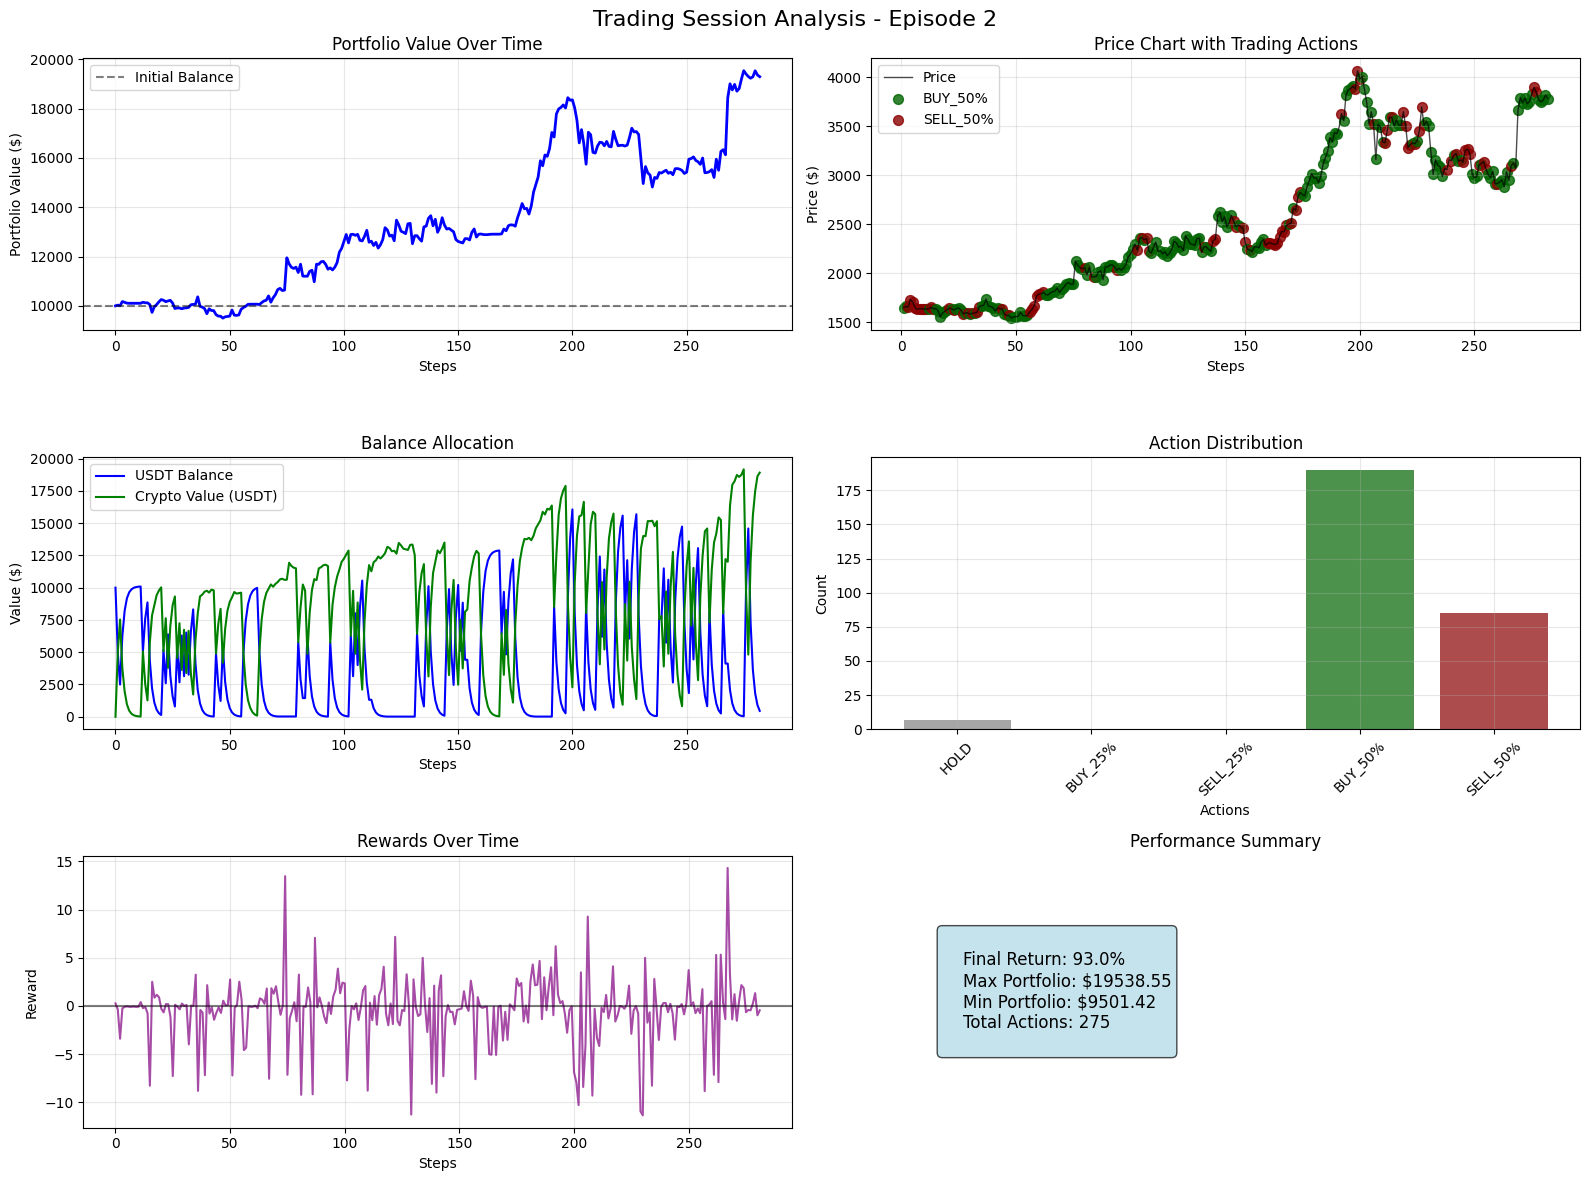


📊 Performance Comparison with Benchmarks
🤖 RL Agent Average Return: +40.56%
📈 Buy & Hold Return: +36.92%
🎲 Random Trading (est.): -5.00%
📊 Agent vs Buy&Hold: +3.64% difference
📉 Agent Return Volatility: 46.78%
🎯 Risk-Adjusted Return: 0.87

🎯 FINAL EVALUATION SUMMARY (Random Time Periods)
📈 Average Return: +40.56%
🔄 Average Trades per Episode: 178.2
💸 Average Fees per Episode: $441.02
💰 Average Final Portfolio: $14055.89

🏆 Best Episode: +92.96% return
   Time Period: 2023-08-26 00:00:00 to 2024-06-03 00:00:00
📉 Worst Episode: -16.66% return
   Time Period: 2024-02-04 00:00:00 to 2024-09-29 00:00:00
📊 Return Range: 109.62%


In [49]:
# IMPROVED EVALUATION: Test on different time periods for better generalization assessment

print("🎯 EVALUATION APPROACH COMPARISON")
print("=" * 70)

# Method 1: Improved Random Time Periods (Recommended)
print("\n🔄 Method 1: Random Different Time Periods")
print("   Each episode tests on a different random time window")
print("   This gives the most realistic performance assessment")

test_results_random = evaluate_agent(
    agent=agent,
    env=test_env,
    episodes=5,  # Test on 5 different time periods
    render_details=True,
    use_different_periods=True  # NEW: Each episode uses different time period
)

# Method 2: Sequential Time Windows (Alternative)
print("\n" + "="*50)
print("\n📅 Method 2: Sequential Non-Overlapping Windows")
print("   Divides test data into sequential periods")
print("   Cleaner separation but less randomization")

test_results_sequential = evaluate_agent_sequential_windows(
    agent=agent,
    env=test_env,
    episodes=4,  # Divide into 4 sequential periods
    render_details=True
)

# Method 3: Original (Same period - for comparison)
print("\n" + "="*50)
print("\n🔁 Method 3: Original Approach (All episodes same period)")
print("   All episodes test on the same time window")
print("   Shows how old approach was potentially misleading")

test_results_original = evaluate_agent(
    agent=agent,
    env=test_env,
    episodes=3,  # Just 3 episodes to show consistency
    render_details=True,
    use_different_periods=False  # OLD: All episodes use same period
)

# COMPARISON ANALYSIS
print("\n" + "="*70)
print("📊 EVALUATION METHOD COMPARISON")
print("="*70)

methods = [
    ("Random Periods", test_results_random),
    ("Sequential Windows", test_results_sequential), 
    ("Original (Same Period)", test_results_original)
]

for method_name, results in methods:
    returns = [r['total_return_pct'] for r in results]
    avg_return = np.mean(returns)
    std_return = np.std(returns)
    win_rate = sum(1 for r in returns if r > 0) / len(returns) * 100
    
    print(f"\n🎯 {method_name}:")
    print(f"   Average Return: {avg_return:+.2f}% (±{std_return:.2f}%)")
    print(f"   Win Rate: {win_rate:.1f}% ({sum(1 for r in returns if r > 0)}/{len(returns)})")
    print(f"   Best/Worst: {max(returns):+.2f}% / {min(returns):+.2f}%")
    print(f"   Episodes: {len(results)}")

# Choose the random periods results as the most reliable
print(f"\n🏆 RECOMMENDED ASSESSMENT: Using Random Periods Method")
print(f"   This provides the most realistic performance evaluation")
test_results = test_results_random  # Use for further analysis

# Detailed Analysis of Best Performing Episode
print(f"\n📊 Detailed Analysis of Best Episode from Random Periods:")
best_episode_idx = np.argmax([r['total_return_pct'] for r in test_results])
best_episode_data = test_results[best_episode_idx]

print(f"   Best Episode: {best_episode_data['episode']}")
print(f"   Time Period: {best_episode_data['start_date']} to {best_episode_data['end_date']}")
print(f"   Return: {best_episode_data['total_return_pct']:+.2f}%")
print(f"   Trades: {best_episode_data['total_trades']}")

plot_trading_session(best_episode_data['data'], episode_num=best_episode_data['episode'])

# Compare with benchmarks using the most reliable results
compare_with_benchmarks(test_results, test_data)

# Final summary
print(f"\n🎯 FINAL EVALUATION SUMMARY (Random Time Periods)")
print("=" * 60)

avg_return = np.mean([r['total_return_pct'] for r in test_results])
avg_trades = np.mean([r['total_trades'] for r in test_results])
avg_fees = np.mean([r['total_fees'] for r in test_results])

print(f"📈 Average Return: {avg_return:+.2f}%")
print(f"🔄 Average Trades per Episode: {avg_trades:.1f}")
print(f"💸 Average Fees per Episode: ${avg_fees:.2f}")
print(f"💰 Average Final Portfolio: ${np.mean([r['final_portfolio_value'] for r in test_results]):.2f}")

# Best and worst episodes with time periods
best_episode = max(test_results, key=lambda x: x['total_return_pct'])
worst_episode = min(test_results, key=lambda x: x['total_return_pct'])

print(f"\n🏆 Best Episode: {best_episode['total_return_pct']:+.2f}% return")
print(f"   Time Period: {best_episode['start_date']} to {best_episode['end_date']}")
print(f"📉 Worst Episode: {worst_episode['total_return_pct']:+.2f}% return") 
print(f"   Time Period: {worst_episode['start_date']} to {worst_episode['end_date']}")
print(f"📊 Return Range: {best_episode['total_return_pct'] - worst_episode['total_return_pct']:.2f}%")
print("=" * 60)


In [ ]:
print("🎓 REINFORCEMENT LEARNING CRYPTO TRADING - CONCLUSIONS")
print("=" * 70)

print("""
🎯 KEY ADVANTAGES OF RL APPROACH:

✅ ACTION-ORIENTED: Learns to take trading actions rather than predict prices
✅ ADAPTIVE: Can adapt to different market conditions through experience
✅ RISK-AWARE: Considers transaction costs and portfolio allocation
✅ HOLISTIC: Learns complete trading strategies, not just entry/exit points
✅ ROBUST: Handles partial information and uncertainty better
✅ SCALABLE: Can incorporate more complex state representations

🔧 POSSIBLE IMPROVEMENTS:

1. MULTI-ASSET: Extend to trade multiple cryptocurrencies
2. ADVANCED FEATURES: Add sentiment data, order book information
3. SOPHISTICATED REWARDS: Use Sharpe ratio, maximum drawdown in rewards
4. ACTOR-CRITIC: Use PPO or A3C for more stable training
5. ENSEMBLE: Combine multiple RL agents for better performance
6. DYNAMIC POSITION SIZING: Learn optimal position sizes
7. RISK MANAGEMENT: Incorporate VaR, maximum drawdown constraints

📊 REALISTIC EXPECTATIONS:

• RL agents can learn patterns but markets are inherently unpredictable
• Performance will vary significantly across different market conditions
• Transaction costs and slippage significantly impact real-world performance
• Requires continuous retraining as market dynamics evolve
• Best used as part of a diversified trading system

🚀 NEXT STEPS:

1. Test on different cryptocurrencies and timeframes
2. Implement more sophisticated reward functions
3. Add risk management constraints
4. Backtest on longer historical periods
5. Paper trade in real-time before risking capital
6. Consider ensemble methods with multiple agents

⚠️  IMPORTANT DISCLAIMER:

This is an educational example. Past performance does not guarantee future results.
Always do your own research and never risk more than you can afford to lose.
Consider this a starting point for learning, not a production trading system.

""")

print("🎉 Thank you for exploring Reinforcement Learning for Crypto Trading!")
print("💡 Remember: The goal is to learn RL concepts, not to get rich quick!")
print("=" * 70)
